# Bank Asset-Liability Management (ALM) Risk Analysis

## Objective
To analyze a simulated bank balance sheet and assess:
- Interest rate risk
- Liquidity risk
- Repricing gap exposure
- Impact of stress scenarios

## Tools
Python (Pandas, Matplotlib)

## Author
Aubrey Likangala

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

UPLOADING DATA

In [3]:
from google.colab import files
files.upload()

Saving liabilities.csv to liabilities.csv
Saving assets.csv to assets.csv


{'liabilities.csv': b'liability_id,type,segment,amount,interest_rate,maturity_years,reprice_freq_years\nL1,Deposits,Current Accounts,1000000,0.02,0.5,0.25\nL2,Deposits,Savings,1200000,0.035,1.0,0.5\nL3,Deposits,Fixed Deposits,900000,0.055,2.0,1.0\nL4,Deposits,Fixed Deposits,700000,0.06,3.0,1.0\nL5,Borrowings,Interbank,600000,0.065,1.0,1.0\nL6,Borrowings,Wholesale Funding,800000,0.07,5.0,2.0\nL7,Borrowings,Bonds Issued,500000,0.075,7.0,3.0\nL8,Deposits,Corporate Deposits,900000,0.045,1.0,0.5\nL9,Deposits,Corporate Deposits,600000,0.05,2.0,1.0\n',
 'assets.csv': b'asset_id,type,segment,amount,interest_rate,maturity_years,reprice_freq_years\nA1,Loans,Retail,800000,0.145,5,1.0\nA2,Loans,Retail,600000,0.135,3,1.0\nA3,Loans,SME,500000,0.125,4,1.0\nA4,Loans,Corporate,1200000,0.11,6,2.0\nA5,Loans,Corporate,900000,0.105,5,2.0\nA6,Bonds,Government,700000,0.085,10,5.0\nA7,Bonds,Government,500000,0.08,7,3.0\nA8,Bonds,Corporate,400000,0.095,8,4.0\nA9,Loans,SME,300000,0.13,2,1.0\nA10,Loans,Retail,25

LOADING DATA

In [8]:
assets = pd.read_csv("assets.csv")
liabilities = pd.read_csv("liabilities.csv")

assets.head()

,asset_id,type,segment,amount,interest_rate,maturity_years,reprice_freq_years
0,A1,Loans,Retail,800000,0.145,5,1.0
1,A2,Loans,Retail,600000,0.135,3,1.0
2,A3,Loans,SME,500000,0.125,4,1.0
3,A4,Loans,Corporate,1200000,0.110,6,2.0
4,A5,Loans,Corporate,900000,0.105,5,2.0


In [9]:
assets = pd.read_csv("assets.csv")
liabilities = pd.read_csv("liabilities.csv")

liabilities.head()

,liability_id,type,segment,amount,interest_rate,maturity_years,reprice_freq_years
0,L1,Deposits,Current Accounts,1000000,0.020,0.5,0.25
1,L2,Deposits,Savings,1200000,0.035,1.0,0.50
2,L3,Deposits,Fixed Deposits,900000,0.055,2.0,1.00
3,L4,Deposits,Fixed Deposits,700000,0.060,3.0,1.00
4,L5,Borrowings,Interbank,600000,0.065,1.0,1.00


BALANCE SHEET OVERVIEW

In [10]:
total_assets = assets['amount'].sum()
total_liabilities = liabilities['amount'].sum()

print("Total Assets:", total_assets)
print("Total Liabilities:", total_liabilities)

Total Assets: 6650000
Total Liabilities: 7200000


NET INTEREST INCOME (NII)

In [11]:
asset_income = (assets['amount'] * assets['interest_rate']).sum()
liability_cost = (liabilities['amount'] * liabilities['interest_rate']).sum()

nii = asset_income - liability_cost
nii

np.float64(393500.0)

NET INTEREST MARGIN (NIM)

In [12]:
nim = nii / total_assets
nim

np.float64(0.059172932330827065)

DURATION GAP

In [13]:
asset_duration = (assets['amount'] * assets['maturity_years']).sum() / total_assets
liability_duration = (liabilities['amount'] * liabilities['maturity_years']).sum() / total_liabilities

duration_gap = asset_duration - liability_duration
duration_gap

np.float64(3.4972848788638258)

TIME BUCKETS

In [15]:
buckets = [0, 1, 3, 5, 10, 100]
labels = ['0-1Y', '1-3Y', '3-5Y', '5-10Y', '10Y+']

assets['bucket'] = pd.cut(assets['maturity_years'], bins=buckets, labels=labels)
liabilities['bucket'] = pd.cut(liabilities['maturity_years'], bins=buckets, labels=labels)

GAP ANALYSIS

In [16]:
asset_bucket = assets.groupby('bucket')['amount'].sum()
liability_bucket = liabilities.groupby('bucket')['amount'].sum()

gap = asset_bucket - liability_bucket

gap_df = pd.DataFrame({
    'Assets': asset_bucket,
    'Liabilities': liability_bucket,
    'Gap': gap
}).fillna(0)

gap_df

/tmp/ipykernel_1199/3209511026.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  asset_bucket = assets.groupby('bucket')['amount'].sum()
/tmp/ipykernel_1199/3209511026.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  liability_bucket = liabilities.groupby('bucket')['amount'].sum()


,Assets,Liabilities,Gap
bucket,,,
0-1Y,450000,3700000,-3250000
1-3Y,900000,2200000,-1300000
3-5Y,2200000,800000,1400000
5-10Y,2800000,500000,2300000
10Y+,300000,0,300000


CUMULATIVE GAP

In [17]:
gap_df['Cumulative Gap'] = gap_df['Gap'].cumsum()
gap_df

,Assets,Liabilities,Gap,Cumulative Gap
bucket,,,,
0-1Y,450000,3700000,-3250000,-3250000
1-3Y,900000,2200000,-1300000,-4550000
3-5Y,2200000,800000,1400000,-3150000
5-10Y,2800000,500000,2300000,-850000
10Y+,300000,0,300000,-550000


VISUALS

Assets vs Liabilities

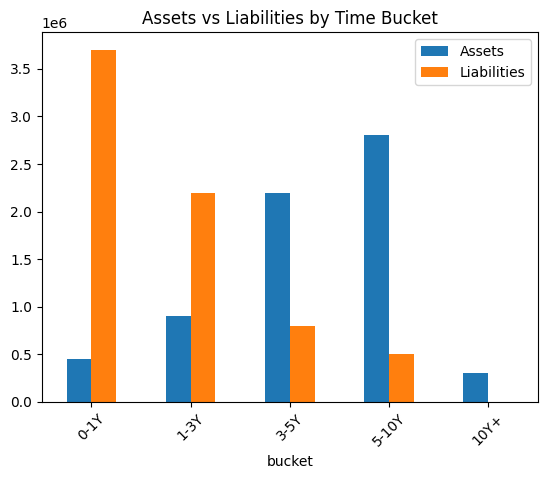

In [18]:
gap_df[['Assets', 'Liabilities']].plot(kind='bar')
plt.title("Assets vs Liabilities by Time Bucket")
plt.xticks(rotation=45)
plt.show()

Gap + Cumulative Gap

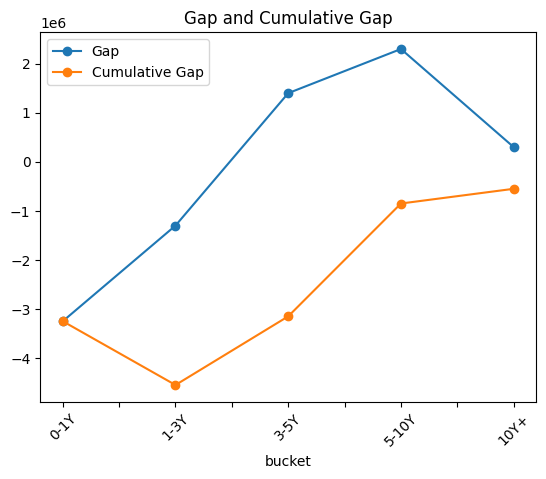

In [19]:
gap_df[['Gap', 'Cumulative Gap']].plot(marker='o')
plt.title("Gap and Cumulative Gap")
plt.xticks(rotation=45)
plt.show()

Portfolio Composition

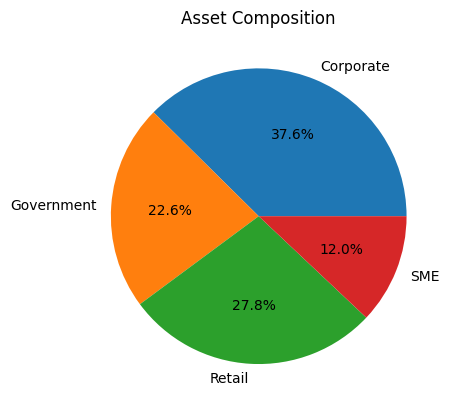

In [20]:
assets.groupby('segment')['amount'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Asset Composition")
plt.ylabel("")
plt.show()

STRESS TEST

In [21]:
assets_stress = assets.copy()
liabilities_stress = liabilities.copy()

# Realistic behavior: liabilities reprice faster
assets_stress['interest_rate'] += 0.01
liabilities_stress['interest_rate'] += 0.02

asset_income_s = (assets_stress['amount'] * assets_stress['interest_rate']).sum()
liability_cost_s = (liabilities_stress['amount'] * liabilities_stress['interest_rate']).sum()

nii_stress = asset_income_s - liability_cost_s
nim_stress = nii_stress / total_assets

print("Base NIM:", nim)
print("Stressed NIM:", nim_stress)

Base NIM: 0.059172932330827065
Stressed NIM: 0.0475187969924812


FINAL INSIGHTS

# Key Insights

## Interest Rate Risk
The bank shows a positive duration gap, indicating exposure to interest rate increases.

## Repricing Risk
Short-term buckets show mismatches between assets and liabilities, exposing the bank to rate volatility.

## Liquidity Risk
Negative gaps in early buckets suggest reliance on short-term funding sources.

## Stress Impact
Under rising rates, liabilities reprice faster than assets, compressing margins.

## Recommendations
- Extend liability maturities  
- Increase fixed-rate lending  
- Improve liquidity buffers  

## Conclusion
The bank is exposed to both interest rate and liquidity risks, requiring active ALM management.